In [119]:
import os
import json
import requests
from tqdm import tqdm
from glob import glob
import csv
from io import StringIO 
from collections import Counter
from math import log
from goatools.obo_parser import GODag
from goatools.anno.gaf_reader import GafReader
from goatools.semantic import TermCounts, get_info_content, resnik_sim

# === CONFIG ===
SPECIES = [9606, 10090, 4932] # human, mouse, yeast
UDF_RESULT = {
    "reliability_score": 0.0,
    "source": "N/A",
    "scores": {}
}

# Gene ontology file for getting DAG structure/relationships
GO_DATA_DIR = "go-data"
go_dag = GODag("go-data/go.obo")
# Gene annotation file for computing term frequencies for information content (IC)
gaf_files = ['goa_human.gaf', 'mgi.gaf', 'fb.gaf'] # human, mouse, fly

# PPI prediction files
DATA_DIR = '../static/data'
FILE_PATTERN = os.path.join(DATA_DIR, "graph_master_part100_*.json")
files = sorted(glob(FILE_PATTERN))
print(f"Found {len(files)} files.")

go-data/go.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms
Found 194 files.


In [172]:
def get_string_id(protein, species):
    url = f"https://string-db.org/api/json/get_string_ids"
    params = {
        "identifiers": protein,
        "species": species
    }
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
        if data:
            return str(data[0]['stringId'])
    except Exception as e:
        print(f"Error resolving {protein} in species {species}: {e}")
    return None

    
def fetch_known_interactors(protein_id, species=9606, limit=50):
    """
    Fetch known interactors from STRING for a given protein.
    """
    url = f"https://string-db.org/api/json/interaction_partners?identifiers={protein_id}"
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        data = r.json()
        return {edge.get("preferredName_B") for edge in data if edge.get("preferredName_B")}
    except Exception as e:
        print(f"Error fetching interactors for {protein_id}: {e}")
        return set()

# checking for direct interaction (UPDATED)
def fetch_string_interaction(source_id, target_id, species=9606):
    url = f"https://string-db.org/api/json/network?identifiers={source_id}%0d{target_id}&species={species}"
    try:
        r = requests.get(url)
        r.raise_for_status()
        data = r.json()
        if not data: 
            return None
        
        score_types = ['ncbiTaxonId', 'score', 'nscore', 'fscore', 'pscore', 'ascore', 'escore', 'dscore', 'tscore']
        edge = data[0]
        if (
            (str(edge.get('preferredName_A')).lower() == str(source_id).lower() \
                and str(edge.get('preferredName_B')).lower() == str(target_id).lower()) or \
            (str(edge.get('preferredName_A')).lower() == str(target_id).lower() \
                and str(edge.get('preferredName_B')).lower() == str(source_id).lower())
        ):
            scores = {field: edge.get(field, 0.0) for field in score_types}
            return scores
    except Exception as e:
        print(f"STRING error: {e}")
        return None
    
    # result = UDF_RESULT.copy()
    # result['ncbiTaxonId'] = species
    # return result

def extract_go_ids(go_terms):
    """Take a set of 'name [GO:xxxx]' strings and return just GO:IDs."""
    ids = set()
    for term in go_terms:
        match = re.search(r'(GO:\d+)', term)
        if match:
            ids.add(match.group(1))
    return ids


def get_protein_info(protein_name):
    """
    Retrieve GO terms and pathways for a protein from UniProt.
    Returns a structured dict instead of raw TSV text.
    """
    base_url = "https://rest.uniprot.org/uniprotkb/search"
    params = {
        "query": protein_name,
        "format": "tsv",
        "fields": (
            "accession,id,protein_name,gene_names,organism_name,"
            "go_f,go_c,go_p,"   # GO terms
            "xref_reactome,xref_kegg",  # pathways
        )
    }
    # go_terms = {"MF": set(), "CC": set(), "BP": set()}
    # pathways = set()
    go_terms = {"BP": set()}
    try:
        r = requests.get(base_url, params=params, timeout=10)
        r.raise_for_status()
        data = r.text
    except Exception as e:
        print(f"[Retriever Error] {e}")
        return go_terms

    reader = csv.DictReader(StringIO(data), delimiter="\t")
    for row in reader: 
        # Extract GO terms
        # if row.get("Gene Ontology (molecular function)"):
        #     go_terms["MF"].update(row["Gene Ontology (molecular function)"].split("; "))
        # if row.get("Gene Ontology (cellular component)"):
        #     go_terms["CC"].update(row["Gene Ontology (cellular component)"].split("; "))
        if row.get("Gene Ontology (biological process)"):
            go_terms["BP"].update(row["Gene Ontology (biological process)"].split("; "))

        # Extract pathways
    #     if row.get("Reactome"):
    #         pathways.update(row["Reactome"].split("; "))
    #     if row.get("KEGG"):
    #         pathways.update(row["KEGG"].split("; "))
    
    return go_terms


def build_ic(gaf_files):
    """
    Compute Information Content (IC) for all terms. 
    Low IC -> common term 
    High IC -> rare term
    """
    annotations = {}
    for gaf_file in gaf_files:
        gaf = GafReader(os.path.join(GO_DATA_DIR, gaf_file))
        annots_bp = gaf.get_ns2assc()["BP"]
        for gene, gos in annots_bp.items():
            annotations.setdefault(gene, set()).update(gos)

    termcounts = TermCounts(go_dag, annotations)
    total = termcounts.get_total_count("biological_process")
    ic = {
        go_id: get_info_content(go_id, termcounts)
        for go_id in termcounts.go2genes
    }

    return ic, termcounts

def compute_resnik_bp(protein_a, protein_b, ic, termcounts, top_n=3):
    """Compute Resnik similarity based on BP terms only."""
    terms_a = extract_go_ids(get_protein_info(protein_a)['BP'])
    terms_b = extract_go_ids(get_protein_info(protein_b)['BP'])
    if not terms_a or not terms_b:
        return {"score": 0.0, "top_terms": []}

    scored_pairs = []
    for a in terms_a:
        for b in terms_b:
            if a in ic and b in ic:
                score = resnik_sim(a, b, go_dag, termcounts)
                scored_pairs.append((a, b, score))

    if not scored_pairs:
        return {"score": 0.0, "top_terms": []}
    scored_pairs.sort(key=lambda x: x[2], reverse=True)
    top_terms = scored_pairs[:top_n]  # Top 3 pairs

    max_ic = max(ic.values())
    normalized_score = scored_pairs[0][2] / max_ic if max_ic > 0 else 0.0

    def go_label(go_id):
        """Helper to get GO name."""
        return go_dag[go_id].name if go_id in go_dag else "Unknown term"

    # Keep top N pairs
    top_terms = [
        {
            "go_a": {"id": a, "name": go_label(a)}, # go id, name
            "go_b": {"id": b, "name": go_label(b)}, 
            "score": round(s / max_ic if max_ic > 0 else 0.0, 3) # similarity score
        }
        for a, b, s in scored_pairs[:top_n]
    ]

    return {
        "score": round(normalized_score, 3),
        "top_terms": top_terms
    }

    
def process_interaction(protein_a, protein_b, ic, termcounts):
    """Compute reliability of interaction."""
    # 1. Try STRING first
    string_scores = fetch_string_interaction(protein_a, protein_b)
    if string_scores:
        return {
            #"interaction": f"{protein_a} -> {protein_b}",
            "reliability_score": string_scores.get("score", 0.0),
            "scores": string_scores
        }
    
    # 2. Else, compute Resnik BP score
    resnik_result = compute_resnik_bp(protein_a, protein_b, ic, termcounts)
    return {
        #"interaction": f"{protein_a} -> {protein_b}",
        "reliability_score": resnik_result["score"],
        "scores": {
            "type": "GO-BP Resnik", 
            "top_terms": resnik_result["top_terms"]
        }
    }

### Updated

Building information content (IC) of biological process (BP) terms. This determines how many genes are annotated to each BP term from GO across all species. This will result in a quick lookup of IC during Resnik similarity calculations

In [160]:
go_dag

{'GO:0000001': GOTerm('GO:0000001'):
   id:GO:0000001
   item_id:GO:0000001
   name:mitochondrion inheritance
   namespace:biological_process
   _parents: 2 items
     GO:0048308
     GO:0048311
   parents: 2 items
     GO:0048308	level-05	depth-05	organelle inheritance [biological_process]
     GO:0048311	level-04	depth-04	mitochondrion distribution [biological_process]
   children: 0 items
   level:5
   depth:6
   is_obsolete:False
   alt_ids: 0 items,
 'GO:0000006': GOTerm('GO:0000006'):
   id:GO:0000006
   item_id:GO:0000006
   name:high-affinity zinc transmembrane transporter activity
   namespace:molecular_function
   _parents: 1 items
     GO:0005385
   parents: 1 items
     GO:0005385	level-07	depth-07	zinc ion transmembrane transporter activity [molecular_function]
   children: 0 items
   level:8
   depth:8
   is_obsolete:False
   alt_ids: 0 items,
 'GO:0000007': GOTerm('GO:0000007'):
   id:GO:0000007
   item_id:GO:0000007
   name:low-affinity zinc ion transmembrane transporte

In [121]:
from goatools.semantic import TermCounts, get_info_content, resnik_sim

ic, termcounts = build_ic(gaf_files)
print(list(ic.items())[:5])

HMS:0:00:16.684881 993,392 annotations READ: go-data/goa_human.gaf 
HMS:0:00:11.398584 785,576 annotations READ: go-data/mgi.gaf 
HMS:0:00:00.721660 138,322 annotations READ: go-data/fb.gaf 
[('GO:0009987', 0.20675643479048902), ('GO:0050794', 0.6843430254747095), ('GO:0050789', 0.652413194340917), ('GO:0065007', 0.6202302076775984), ('GO:0007165', 1.7469455099891114)]


Testing Resnik similarity across different PPI predictions. 
- POFUT1 -> F7 should be a valid interaction in STRING
- ABI1 -> GPX1 and A4GNT -> RAD50 are not found in STRING, should compute Resnik similarity on BP terms

In [163]:
from pprint import pprint 

test_source = "POFUT1"
test_target = "F7"

score = process_interaction(test_source, test_target, ic, termcounts)
#print(f"Confidence scores for interaction {test_source} -> {test_target}: {score}")
pprint(score, indent=2, width=100)

{ 'reliability_score': 0.824,
  'scores': { 'ascore': 0.047,
              'dscore': 0,
              'escore': 0.797,
              'fscore': 0,
              'ncbiTaxonId': '9606',
              'nscore': 0,
              'pscore': 0,
              'score': 0.824,
              'tscore': 0.167}}


In [173]:
# test_source = "ABI1"
# test_target = "GPX1"

test_source = "A4GNT"
test_target = "RAD50"
score = process_interaction(test_source, test_target, ic, termcounts)
print(f"Confidence scores for interaction {test_source} -> {test_target}:")
pprint(score, indent=2, width=100)

Confidence scores for interaction A4GNT -> RAD50:
{ 'reliability_score': 0.218,
  'scores': { 'top_terms': [ { 'go_a': { 'id': 'GO:0006493',
                                         'name': 'protein O-linked glycosylation'},
                               'go_b': { 'id': 'GO:0007004',
                                         'name': 'telomere maintenance via telomerase'},
                               'score': 0.218},
                             { 'go_a': { 'id': 'GO:0016266',
                                         'name': 'protein O-linked glycosylation via '
                                                 'N-acetyl-galactosamine'},
                               'go_b': { 'id': 'GO:0007004',
                                         'name': 'telomere maintenance via telomerase'},
                               'score': 0.218},
                             { 'go_a': { 'id': 'GO:0009101',
                                         'name': 'glycoprotein biosynthetic process'},
       

In [174]:
test_source = "ABI1"
test_target = "GPX1"
score = process_interaction(test_source, test_target, ic, termcounts)
print(f"Confidence scores for interaction {test_source} -> {test_target}:")
pprint(score, indent=2, width=100)

Confidence scores for interaction ABI1 -> GPX1:
{ 'reliability_score': 0.698,
  'scores': { 'top_terms': [ { 'go_a': {'id': 'GO:0051450', 'name': 'myoblast proliferation'},
                               'go_b': {'id': 'GO:0051450', 'name': 'myoblast proliferation'},
                               'score': 0.698},
                             { 'go_a': {'id': 'GO:0048144', 'name': 'fibroblast proliferation'},
                               'go_b': {'id': 'GO:0048144', 'name': 'fibroblast proliferation'},
                               'score': 0.614},
                             { 'go_a': {'id': 'GO:0043542', 'name': 'endothelial cell migration'},
                               'go_b': { 'id': 'GO:0043534',
                                         'name': 'blood vessel endothelial cell migration'},
                               'score': 0.539}],
              'type': 'GO-BP Resnik'}}


In [ ]:
import requests
from collections import defaultdict

def shared_annotations(protein1, protein2, species):
    categories = ["COMPARTMENTS", "PROCESS", "FUNCTION"]
    url = "https://string-db.org/api/json/functional_annotation"
    genes = [protein1, protein2]

    shared = defaultdict(set)
    term_map = defaultdict(lambda: defaultdict(set)) 
    term_descriptions = defaultdict(dict) 

    for gene in genes:
        response = requests.get(url, params={"identifiers": gene, "species": species})
        annotations = response.json()

        for entry in annotations:
            cat = entry["category"].upper()  
            if cat in categories:
                term = entry["term"]
                desc = entry["description"]
                term_map[cat][term].add(gene)
                term_descriptions[cat][term] = desc

    # Finding shared terms
    for cat in categories: 
        for term_id, gene_set in term_map[cat].items():
            if protein1 in gene_set and protein2 in gene_set:
                shared[cat].add((term_id, term_descriptions[cat][term_id]))

    return shared

shared = shared_annotations("ABI1", "GPX1", 10090)
for cat, terms in shared.items():
    print(f"{cat}:")
    for term_id, description in terms:
        print(f"  - {term_id}: {description}")

COMPARTMENTS:
  - GOCC:0005622: Intracellular
  - GOCC:0110165: Cellular anatomical entity
  - GOCC:0005737: Cytoplasm
  - GOCC:0032991: Protein-containing complex
  - GOCC:0043226: Organelle
PROCESS:
  - GO:0007165: Signal transduction
  - GO:0048856: Anatomical structure development
  - GO:0006807: Nitrogen compound metabolic process
  - GO:0051246: Regulation of protein metabolic process
  - GO:0048468: Cell development
  - GO:0050896: Response to stimulus
  - GO:0032502: Developmental process
  - GO:0051171: Regulation of nitrogen compound metabolic process
  - GO:0043412: Macromolecule modification
  - GO:0065009: Regulation of molecular function
  - GO:0009888: Tissue development
  - GO:0048731: System development
  - GO:0007275: Multicellular organism development
  - GO:0030154: Cell differentiation
  - GO:1901564: Organonitrogen compound metabolic process
  - GO:0048646: Anatomical structure formation involved in morphogenesis
  - GO:0050789: Regulation of biological process
  

Testing on two proteins that aren't found

In [175]:
source = "zzzzccbbaaMBqqqqqqweweew333"
target = "MwewB33333"
score = process_interaction(source, target, ic, termcounts)
print(f"Confidence scores for interaction {source} -> {target}:")
pprint(score, indent=2, width=100)

STRING error: 404 Client Error: Not Found for url: https://string-db.org/api/json/network?identifiers=zzzzccbbaaMBqqqqqqweweew333%0DMwewB33333&species=9606
Confidence scores for interaction zzzzccbbaaMBqqqqqqweweew333 -> MwewB33333:
{'reliability_score': 0.0, 'scores': {'top_terms': [], 'type': 'GO-BP Resnik'}}


In [30]:
import re

def extract_number(filename):
    match = re.search(r'(\d+)\.json$', filename)
    return int(match.group(1)) if match else -1

files = sorted(files, key=extract_number)
filelist = files[:10]
filelist

['../static/data/graph_master_part100_0.json',
 '../static/data/graph_master_part100_1.json',
 '../static/data/graph_master_part100_2.json',
 '../static/data/graph_master_part100_3.json',
 '../static/data/graph_master_part100_4.json',
 '../static/data/graph_master_part100_5.json',
 '../static/data/graph_master_part100_6.json',
 '../static/data/graph_master_part100_7.json',
 '../static/data/graph_master_part100_8.json',
 '../static/data/graph_master_part100_9.json']

### Link processing

In [176]:
import time
from gseapy import enrichr
from concurrent.futures import ThreadPoolExecutor, as_completed

for file in tqdm(filelist):
    with open(file, "r") as f:
        data = json.load(f)

    # processing nodes 
    nodes = data.get("nodes", [])

    data["nodes"] = nodes

    # processing links
    links = data.get("links", [])
    new_links = []

    for link in links:
        start = time.time()

        src = str(link["source"])
        tgt = str(link["target"])
        id = str(link["id"])
        color = link.get("color") 
        penwidth = link.get("penwidth")

        scores = process_interaction(src, tgt, ic, termcounts)
        link_data = {
            "source": src,
            "target": tgt,
            "id": id,
            **scores
        }
        if color is not None:
            link_data["color"] = color
        if penwidth is not None:
            link_data["penwidth"] = penwidth
        
        new_links.append(link_data)

    data["links"] = new_links

    # saving new data
    OUTPUT_DIR = "../static/data/graph_master_scored"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    filename = os.path.basename(file)
    outname = os.path.join(OUTPUT_DIR, filename)
    with open(outname, "w") as f:
        json.dump(data, f, indent=2)

  0%|          | 0/10 [00:00<?, ?it/s]

STRING error: 404 Client Error: Not Found for url: https://string-db.org/api/json/network?identifiers=zzzzccbbaaMBqqqqqqweweew333%0DMwewB33333&species=9606


 20%|██        | 2/10 [05:48<27:17, 204.66s/it]

STRING error: 525 Server Error:  for url: https://string-db.org/api/json/network?identifiers=PER2%0DCLOCK&species=9606


100%|██████████| 10/10 [36:30<00:00, 219.09s/it]


Reading graph files

In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm import tqdm
from glob import glob

DATA_DIR = '../static/data/graph_master_scored'
FILE_PATTERN = os.path.join(DATA_DIR, "graph_master_part100_*.json")
files = sorted(glob(FILE_PATTERN))
print(f"Found {len(files)} files.")

Found 5 files.


In [2]:
scores = []
total_nodes = 0
total_links = 0

for file in files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        nodes = data.get("nodes", [])
        links = data.get("links", [])
        total_nodes += len(nodes)
        total_links += len(links)
        print(f"{file} has {len(links)} links")
        # print(f"{file} has {len(nodes)} nodes")

        for interaction in links:
            scores.append(interaction.get("score", 0.0))

print(f"Collected {len(scores)} scores for graph size {total_nodes}, {total_links}.")

../static/data/graph_master_scored/graph_master_part100_0.json has 1 links
../static/data/graph_master_scored/graph_master_part100_1.json has 294 links
../static/data/graph_master_scored/graph_master_part100_2.json has 342 links
../static/data/graph_master_scored/graph_master_part100_3.json has 209 links
../static/data/graph_master_scored/graph_master_part100_4.json has 199 links
Collected 1045 scores for graph size 402, 1045.


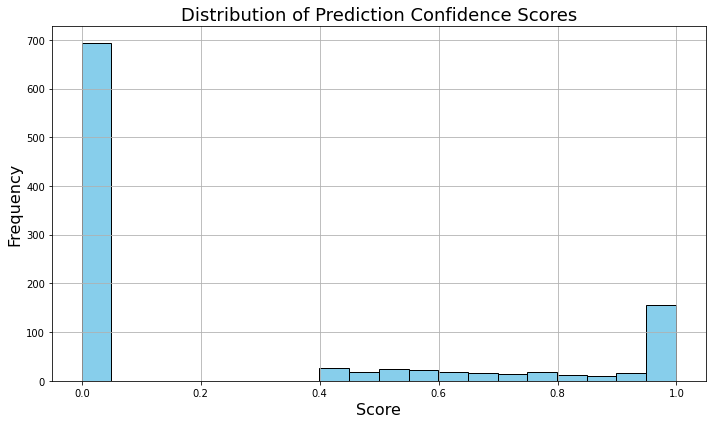

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(scores, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Prediction Confidence Scores', fontsize=18)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.xlabel('Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

In [123]:
zero_scores = sum(1 for score in scores if score == 0.0)
total_scores = len(scores)

if total_scores > 0:
    percent_zero = (zero_scores / total_scores) * 100
    print(f"Zero scores: {zero_scores} / {total_scores} ({percent_zero:.2f}%)")
else:
    print("No scores found.")

Zero scores: 692 / 1050 (65.90%)


In [124]:
non_zero_scores = [s for s in scores if s > 0.0]
high_scores = [s for s in non_zero_scores if 0.9 <= s <= 1.0]

if non_zero_scores:
    percent_high = (len(high_scores) / len(non_zero_scores)) * 100
    print(f"Scores between 0.9 and 1.0: {len(high_scores)} / {len(non_zero_scores)} ({percent_high:.2f}%)")

Scores between 0.9 and 1.0: 176 / 358 (49.16%)


In [ ]:
from collections import defaultdict 

node_interaction_counts = defaultdict(int)

for file in files:
    with open(file, 'r') as f:
        data = json.load(f)
        links = data.get("links", [])
        for link in links:
            source = link.get("source")
            target = link.get("target")
            if source:
                node_interaction_counts[source] += 1
            if target:
                node_interaction_counts[target] += 1

In [34]:
len(node_interaction_counts)

486

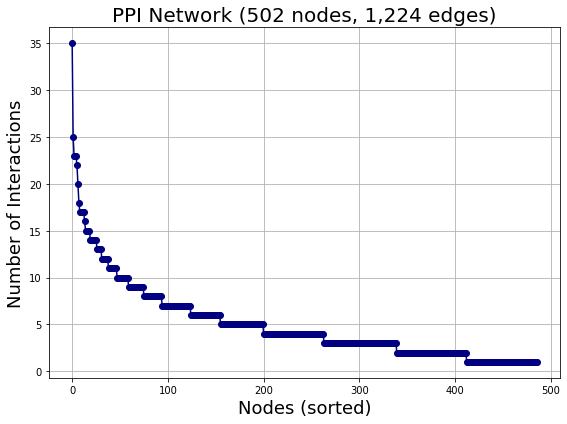

In [ ]:
# Sort nodes by interaction counts (descending)
sorted_nodes_counts = sorted(node_interaction_counts.items(), key=lambda x: x[1], reverse=True)
nodes_sorted, counts_sorted = zip(*sorted_nodes_counts)

# Plot interaction counts ordered by node rank
plt.figure(figsize=(8, 6))
plt.plot(counts_sorted, marker='o', linestyle='-', color='navy')
plt.title('PPI Network (502 nodes, 1,224 edges)', fontsize=20)
plt.xlabel('Nodes (sorted)', fontsize=18)
plt.ylabel('Number of Interactions', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.show()

Running KEGG enrichment with gprofiler

In [6]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
gene_list = [node["id"] for node in data["nodes"]]
results = gp.profile(
    organism="hsapiens",  # or "mmusculus", "scerevisiae"
    query=gene_list,
    sources=["KEGG"]
)

In [24]:
len(gene_list)

100

In [17]:
results

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,KEGG,KEGG:02010,ABC transporters,7.964192e-09,True,ABC transporters,45,72,9,8484,0.125000,0.200000,query_1,[KEGG:00000]
1,KEGG,KEGG:05203,Viral carcinogenesis,8.376104e-08,True,Viral carcinogenesis,201,72,14,8484,0.194444,0.069652,query_1,[KEGG:00000]
2,KEGG,KEGG:05200,Pathways in cancer,1.010423e-07,True,Pathways in cancer,527,72,21,8484,0.291667,0.039848,query_1,[KEGG:00000]
3,KEGG,KEGG:05207,Chemical carcinogenesis - receptor activation,1.574357e-06,True,Chemical carcinogenesis - receptor activation,211,72,13,8484,0.180556,0.061611,query_1,[KEGG:00000]
4,KEGG,KEGG:05219,Bladder cancer,3.535299e-06,True,Bladder cancer,41,72,7,8484,0.097222,0.170732,query_1,[KEGG:00000]
5,KEGG,KEGG:05225,Hepatocellular carcinoma,1.045637e-05,True,Hepatocellular carcinoma,166,72,11,8484,0.152778,0.066265,query_1,[KEGG:00000]
6,KEGG,KEGG:04110,Cell cycle,5.948851e-05,True,Cell cycle,157,72,10,8484,0.138889,0.063694,query_1,[KEGG:00000]
7,KEGG,KEGG:05215,Prostate cancer,1.202492e-04,True,Prostate cancer,97,72,8,8484,0.111111,0.082474,query_1,[KEGG:00000]
8,KEGG,KEGG:05034,Alcoholism,2.930813e-04,True,Alcoholism,187,72,10,8484,0.138889,0.053476,query_1,[KEGG:00000]
9,KEGG,KEGG:04919,Thyroid hormone signaling pathway,6.367563e-04,True,Thyroid hormone signaling pathway,121,72,8,8484,0.111111,0.066116,query_1,[KEGG:00000]


KEGG enrichment with GSEApy (https://github.com/zqfang/GSEApy)

In [37]:
import gseapy as gsea

enr = gsea.enrichr(
    gene_list=gene_list,
    gene_sets="KEGG_2021_Human",  
    organism="human",             
    outdir=None                 
)

In [8]:
enr.results.shape

(207, 10)

Incremental update to GSEApy

Initial load

In [63]:
human_scores = []
total_nodes = 0
total_links = 0

for i in range(5):
    file = files[i]
    with open(file, 'r') as f:
        data = json.load(f)
        
        nodes = data.get("nodes", [])
        links = data.get("links", [])
        total_nodes += len(nodes)
        total_links += len(links)
        print(f"{file} has {len(links)} links")
        # print(f"{file} has {len(nodes)} nodes")

        for interaction in links:
            if "9606" in interaction:
                human_score = interaction["9606"].get("score", 0.0)
                mouse_score = interaction.get("10090", {}).get("score", 0.0)
                yeast_score = interaction.get("4932", {}).get("score", 0.0)

                # Only include if human score is non-zero OR if all scores are zero
                if human_score != 0.0 or (mouse_score == 0.0 and yeast_score == 0.0):
                    human_scores.append(human_score) 

gene_list = [node["id"] for node in data["nodes"]]
enr = gsea.enrichr(
    gene_list=gene_list,
    gene_sets="KEGG_2021_Human",  
    organism="human",             
    outdir=None                 
)

../static/data/graph_master_scored/graph_master_part100_0.json has 1 links
../static/data/graph_master_scored/graph_master_part100_1.json has 294 links
../static/data/graph_master_scored/graph_master_part100_2.json has 342 links
../static/data/graph_master_scored/graph_master_part100_3.json has 209 links
../static/data/graph_master_scored/graph_master_part100_4.json has 199 links


In [64]:
enr.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,ABC transporters,20/45,3.606117e-35,8.005579e-33,0,0,198.750000,15762.434538,ABCC3;ABCG8;ABCC1;ABCG5;ABCD3;ABCC2;ABCA5;ABCA...
1,KEGG_2021_Human,Bile secretion,9/90,6.838687e-10,7.590943e-08,0,0,24.199023,510.678161,ABCC3;ABCG8;ABCG5;ABCC2;RXRA;ABCB4;ABCB11;CYP3...
2,KEGG_2021_Human,Cholesterol metabolism,7/50,5.288019e-09,3.913134e-07,0,0,34.758440,662.420162,CYP27A1;ABCG8;ABCG5;CD36;LRP2;LDLRAP1;ABCB11
3,KEGG_2021_Human,Focal adhesion,10/201,6.630594e-08,3.679980e-06,0,0,11.465387,189.511222,PDGFRA;MAPK8;RAP1A;PRKCB;CAV2;ERBB2;FN1;CTNNB1...
4,KEGG_2021_Human,Proteoglycans in cancer,9/205,8.905705e-07,3.954133e-05,0,0,9.942588,138.514207,MRAS;PRKCB;CAV2;ERBB2;GPC3;FN1;CTNNB1;PRKCA;IGF1R
...,...,...,...,...,...,...,...,...,...,...
217,KEGG_2021_Human,Viral carcinogenesis,1/203,6.403882e-01,6.521385e-01,0,0,0.984998,0.438995,IRF3
218,KEGG_2021_Human,Human T-cell leukemia virus 1 infection,1/219,6.683867e-01,6.775427e-01,0,0,0.911964,0.367420,MAPK8
219,KEGG_2021_Human,Parkinson disease,1/249,7.151927e-01,7.185155e-01,0,0,0.800424,0.268305,MAPK8
220,KEGG_2021_Human,Herpes simplex virus 1 infection,2/498,7.152789e-01,7.185155e-01,0,0,0.798387,0.267526,IFNG;IRF3


In [41]:
import pandas as pd 
from collections import defaultdict

file = files[-1]
merged = defaultdict(list)
with open(file, 'r') as f:
    new_data = json.load(f)
    nodes = new_data.get("nodes", [])
    links = new_data.get("links", [])
    total_nodes += len(nodes)
    total_links += len(links)

    print(f"{file} has {len(links)} links")

    for interaction in links:
        if "9606" in interaction:
            human_score = interaction["9606"].get("score", 0.0)
            mouse_score = interaction.get("10090", {}).get("score", 0.0)
            yeast_score = interaction.get("4932", {}).get("score", 0.0)

            # Only include if human score is non-zero OR if all scores are zero
            if human_score != 0.0 or (mouse_score == 0.0 and yeast_score == 0.0):
                human_scores.append(human_score) 

../static/data/graph_master_scored/graph_master_part100_5.json has 179 links


In [137]:
new_gene_list = [node["id"] for node in new_data["nodes"]]
enr = gsea.enrichr(
    gene_list=new_gene_list,
    gene_sets=["KEGG_2021_Human", "GO_Biological_Process_2021"],  
    organism="human",             
    outdir=None                 
)

In [139]:
enr.results[['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Genes']]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Genes
0,KEGG_2021_Human,Pathways in cancer,21/531,1.583534e-13,3.277915e-11,ITGB1;TCF7L1;HDAC2;GADD45A;LEF1;BRCA2;EPOR;HSP...
1,KEGG_2021_Human,ABC transporters,9/45,1.032061e-12,1.068183e-10,ABCC4;ABCB6;ABCB7;ABCB8;ABCC9;ABCB9;ABCC11;ABC...
2,KEGG_2021_Human,Viral carcinogenesis,14/203,1.611734e-12,1.112097e-10,HDAC4;HDAC5;HDAC2;HDAC3;SRC;HDAC8;HDAC9;HDAC6;...
3,KEGG_2021_Human,Chemical carcinogenesis,13/239,2.071855e-10,1.072185e-08,UGT1A1;SRC;ARRB1;HSP90B1;VEGFA;NRAS;GSTA4;CCND...
4,KEGG_2021_Human,Hepatocellular carcinoma,11/168,7.850059e-10,3.249924e-08,NRAS;TCF7L1;GSTA4;CCND1;GSTA3;GADD45A;GSTA2;GS...
...,...,...,...,...,...,...
1740,GO_Biological_Process_2021,regulation of cell growth (GO:0001558),1/217,6.650086e-01,6.667426e-01,CEACAM1
1741,GO_Biological_Process_2021,regulation of cellular macromolecule biosynthe...,2/468,6.825875e-01,6.839215e-01,TCF7L1;BRCA2
1742,GO_Biological_Process_2021,positive regulation of cytokine production (GO...,1/335,8.161088e-01,8.171714e-01,IRF4
1743,GO_Biological_Process_2021,gene expression (GO:0010467),1/356,8.347880e-01,8.353311e-01,RANBP2


<Axes: title={'center': 'Gene Set Enrichment'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

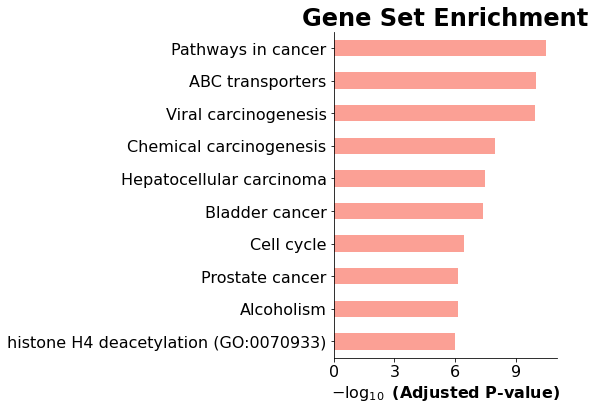

In [127]:
gsea.barplot(enr.results, title='Gene Set Enrichment', cutoff=0.05)

<Axes: title={'center': 'Top Terms'}, xlabel='Combined Score'>

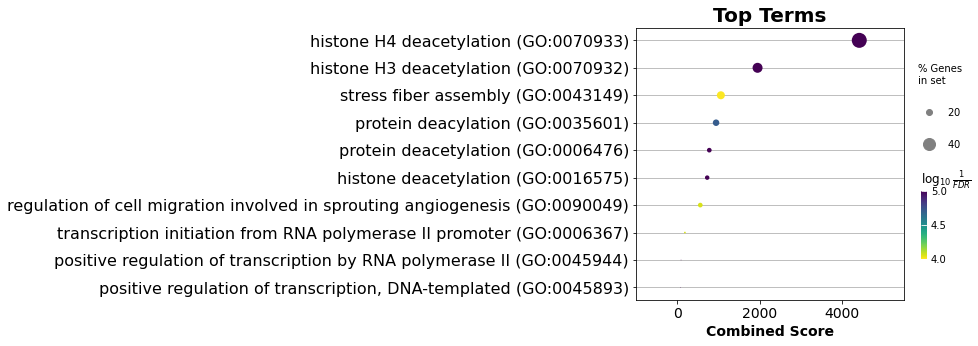

In [135]:
from gseapy import barplot, dotplot

dotplot(enr.res2d, 
        title='Top Terms', 
        cutoff=0.05, 
        figsize=(6,5))